# SEIRS-SEI Malaria Model — Weighted Initial Condition Calibration

Calibrating **S_H0_frac**, **E_H0_frac**, and **I_M0_ratio** (2012 initial conditions) with **time-weighted optimization** to better fit the initial decline in infected cases.

## Problem Statement

The model's initial conditions in 2012 (S_H0, E_H0, I_M0) control the warm-up trajectory (2012-2016) and determine the state at the start of the fitting period (2017). Weighted optimization gives more importance to early time periods to better capture initial dynamics.

**Parameters being calibrated:**
- **S_H0_frac**: S_H0 / N_2012 (proportion of susceptible humans)
- **E_H0_frac**: E_H0 / N_2012 (proportion of exposed humans)
- **I_M0_ratio**: I_M0 / M_0_2012 (proportion of infectious mosquitoes)

**R_H0** is computed as residual: `R_H0 = N - S_H0 - E_H0 - I_H0`, constrained to [1%, 85%] of N.
**E_M0** is estimated as `round(I_M0 * 2.5)`.

**Weight Decay Methods:**
- **Exponential**: `weight = W0 * exp(-rate * days)` - Smooth, continuous decay
- **Step**: Higher weight for first year, then lower weight
- **Inverse**: `weight = W0 * (1 / (1 + days/365))` - Year-based decay

**Fixed**: Fitted humidity, human transmission, and force of infection parameters from previous calibrations.

**Default values**: S_H0_frac=0.60, E_H0_frac=0.05, I_M0_ratio=0.01

---
**Resumable execution**: Results are saved to `calibration_results_ic.json` after each section.
If the notebook is interrupted, re-run from the top — completed sections will be loaded from file and skipped.

In [2]:
from weighted_optimization_shared import *
%matplotlib inline
import warnings, json, os
warnings.filterwarnings("ignore")
from scipy.optimize import minimize
import itertools

Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
Loaded fitted human params from exponential: tau_H=21.0000, gamma=0.008333, omega=0.005556

Initial human compartments in 2012: N=8914, S_H=5365, E_H=446, I_H=1766, R_H=1337
Initial mosquito compartments in 2012: M=89140, S_M=85576, E_M=2673, I_M=891
Loaded fitted FoI params from exponential: b1=0.040000, b2=0.090000


In [3]:
RESULTS_FILE = os.path.join(os.getcwd(), 'calibration_results_ic.json')

S_H0_candidates = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.45]
E_H0_candidates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.04]
bounds = [(0.05, 0.95), (0.005, 0.50), (0.0005, 0.10)]
decay_rate = 0.005
initial_weight = 5.0
step_initial_weight = 5.0
step_later_weight = 1.0
inverse_scale = 365

saved = {}
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, 'r') as f:
        saved = json.load(f)
    print(f"Loaded saved results from {RESULTS_FILE}")
    for method, params in saved.items():
        print(f"  {method}: S_H0_frac={params['S_H0_frac']:.4f}, E_H0_frac={params['E_H0_frac']:.4f}, I_M0_ratio={params['I_M0_ratio']:.6f}")
else:
    print("No saved results found — will run all grid searches.")
    
grid_size = len(S_H0_candidates) * len(E_H0_candidates) * len(I_M0_candidates)

if 'exponential' in saved:
    S_H0_optimal_exp = saved['exponential']['S_H0_frac']
    E_H0_optimal_exp = saved['exponential']['E_H0_frac']
    I_M0_optimal_exp = saved['exponential']['I_M0_ratio']
if 'step' in saved:
    S_H0_optimal_step = saved['step']['S_H0_frac']
    E_H0_optimal_step = saved['step']['E_H0_frac']
    I_M0_optimal_step = saved['step']['I_M0_ratio']
if 'inverse' in saved:
    S_H0_optimal_inv = saved['inverse']['S_H0_frac']
    E_H0_optimal_inv = saved['inverse']['E_H0_frac']
    I_M0_optimal_inv = saved['inverse']['I_M0_ratio']

No saved results found — will run all grid searches.


In [4]:
def save_result(method_name, S_H0_frac, E_H0_frac, I_M0_ratio):
    data = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}
    data[method_name] = {'S_H0_frac': float(S_H0_frac), 'E_H0_frac': float(E_H0_frac), 'I_M0_ratio': float(I_M0_ratio)}
    with open(RESULTS_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"  Saved {method_name} results to {RESULTS_FILE}")

---
## Section 1: Understanding the Weighting Approach

Before calibrating, let's understand how different weight functions affect the optimization.

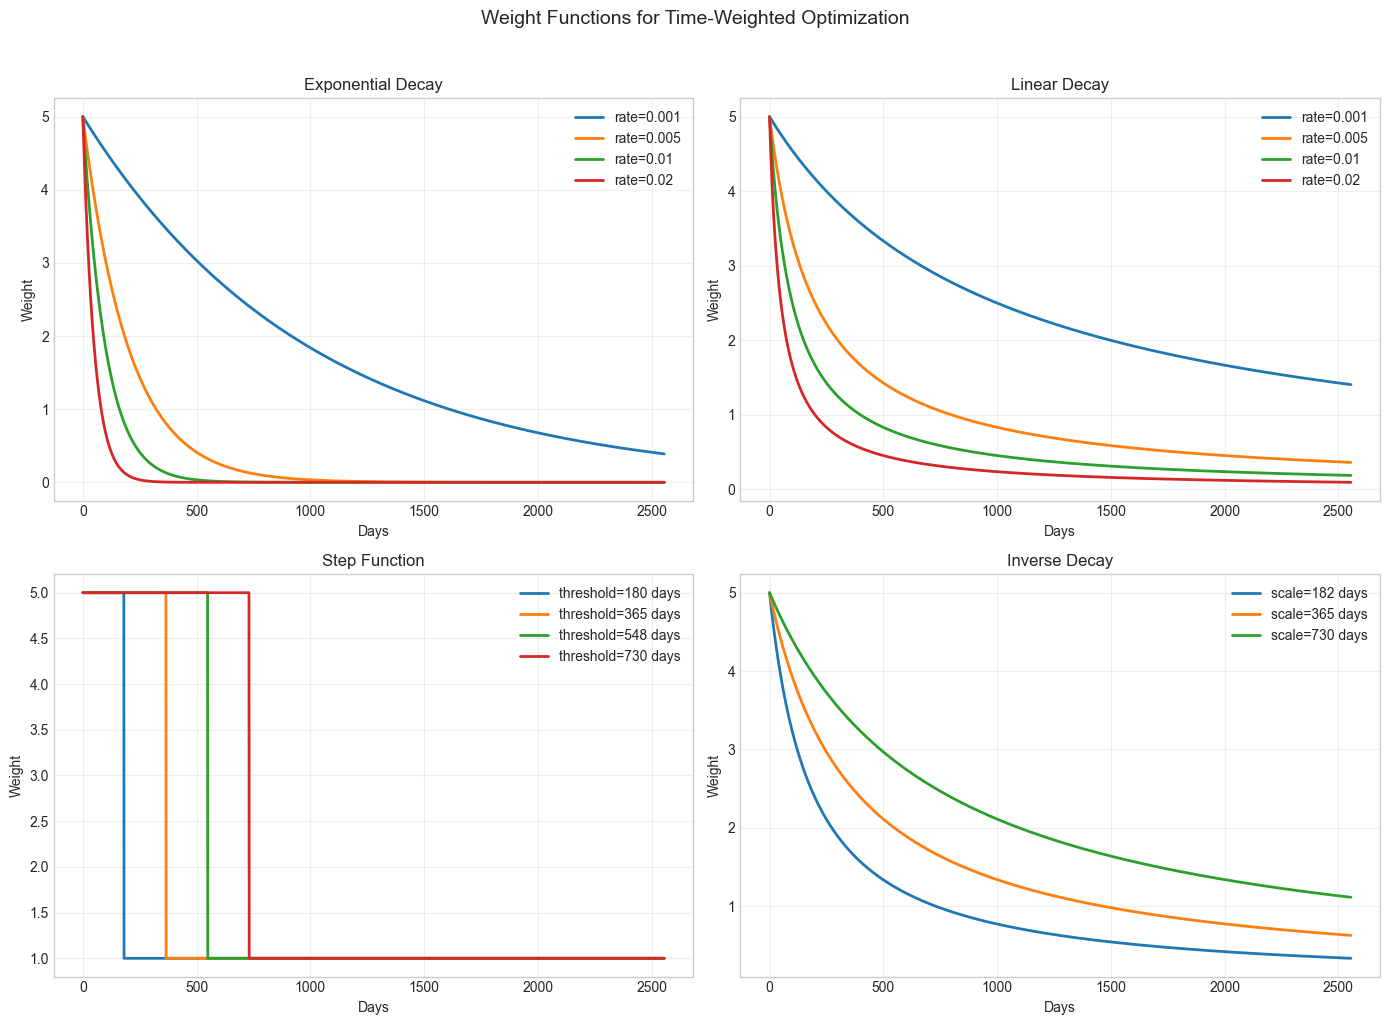

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
days = np.arange(0, 2556, 1)

ax1 = axes[0, 0]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax1.plot(days, 5.0 * np.exp(-rate * days), linewidth=2, label=f'rate={rate}')
ax1.set_title('Exponential Decay'); ax1.set_xlabel('Days'); ax1.set_ylabel('Weight'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax2.plot(days, 5.0 / (1 + rate * days), linewidth=2, label=f'rate={rate}')
ax2.set_title('Linear Decay'); ax2.set_xlabel('Days'); ax2.set_ylabel('Weight'); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
for thresh in [180, 365, 548, 730]:
    w = np.where(days <= thresh, 5.0, 1.0)
    ax3.plot(days, w, linewidth=2, label=f'threshold={thresh} days')
ax3.set_title('Step Function'); ax3.set_xlabel('Days'); ax3.set_ylabel('Weight'); ax3.legend(); ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for scale in [182, 365, 730]:
    ax4.plot(days, 5.0 * (1.0 / (1.0 + days / scale)), linewidth=2, label=f'scale={scale} days')
ax4.set_title('Inverse Decay'); ax4.set_xlabel('Days'); ax4.set_ylabel('Weight'); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle('Weight Functions for Time-Weighted Optimization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2: Grid Search with Exponential Weighting

In [8]:
if 'exponential' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Exponential Weighting")
    print("=" * 70)
    grid_size = len(S_H0_candidates) * len(E_H0_candidates) * len(I_M0_candidates)
    print(f"Grid size: {len(S_H0_candidates)} x {len(E_H0_candidates)} x {len(I_M0_candidates)} = {grid_size}")
    print(f"Weight: exponential decay, rate={decay_rate}, initial_weight={initial_weight}")
    print()

    best_params_exp = None
    best_mse_exp = 1e15

    for s, e, im in itertools.product(S_H0_candidates, E_H0_candidates, I_M0_candidates):
        mse = objective_function_weighted_ic([s, e, im],
                                         weight_decay='exponential',
                                         decay_rate=decay_rate,
                                         initial_weight=initial_weight)
        if mse < best_mse_exp:
            best_mse_exp = mse
            best_params_exp = (s, e, im)
        print(f"  S_H0={s:.3f}, E_H0={e:.3f}, I_M0={im:.3f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Exponential): S_H0={best_params_exp[0]:.3f}, E_H0={best_params_exp[1]:.3f}, I_M0={best_params_exp[2]:.3f}")
    print(f"  Weighted MSE = {best_mse_exp:,.2f}")
else:
    print("Exponential results already loaded — skipping grid search.")
    best_params_exp = (S_H0_optimal_exp, E_H0_optimal_exp, I_M0_optimal_exp)

GRID SEARCH: Exponential Weighting
Grid size: 7 x 7 x 6 = 294
Weight: exponential decay, rate=0.005, initial_weight=5.0

  S_H0=0.050, E_H0=0.050, I_M0=0.001 -> Weighted MSE=1,301,888.64
  S_H0=0.050, E_H0=0.050, I_M0=0.002 -> Weighted MSE=1,302,085.75
  S_H0=0.050, E_H0=0.050, I_M0=0.005 -> Weighted MSE=1,301,832.55
  S_H0=0.050, E_H0=0.050, I_M0=0.010 -> Weighted MSE=1,304,145.55
  S_H0=0.050, E_H0=0.050, I_M0=0.020 -> Weighted MSE=1,298,713.70
  S_H0=0.050, E_H0=0.050, I_M0=0.040 -> Weighted MSE=1,300,675.61
  S_H0=0.050, E_H0=0.100, I_M0=0.001 -> Weighted MSE=1,294,723.71
  S_H0=0.050, E_H0=0.100, I_M0=0.002 -> Weighted MSE=1,290,555.63
  S_H0=0.050, E_H0=0.100, I_M0=0.005 -> Weighted MSE=1,290,119.12
  S_H0=0.050, E_H0=0.100, I_M0=0.010 -> Weighted MSE=1,289,935.02
  S_H0=0.050, E_H0=0.100, I_M0=0.020 -> Weighted MSE=1,290,080.61
  S_H0=0.050, E_H0=0.100, I_M0=0.040 -> Weighted MSE=1,288,448.95
  S_H0=0.050, E_H0=0.150, I_M0=0.001 -> Weighted MSE=1,281,590.07
  S_H0=0.050, E_H0=0.

In [9]:
if 'exponential' not in saved:
    print("Fine optimization with L-BFGS-B (Exponential)...")
    result_exp = minimize(
        lambda p: objective_function_weighted_ic(p, weight_decay='exponential',
                                             decay_rate=decay_rate, initial_weight=initial_weight),
        list(best_params_exp), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    S_H0_optimal_exp, E_H0_optimal_exp, I_M0_optimal_exp = result_exp.x
    print(f"  S_H0_frac={S_H0_optimal_exp:.4f}, E_H0_frac={E_H0_optimal_exp:.4f}, I_M0_ratio={I_M0_optimal_exp:.6f}")
    print(f"  Weighted MSE = {result_exp.fun:,.2f}")
    save_result('exponential', S_H0_optimal_exp, E_H0_optimal_exp, I_M0_optimal_exp)
else:
    print(f"Exponential: S_H0_frac={S_H0_optimal_exp:.4f}, E_H0_frac={E_H0_optimal_exp:.4f}, I_M0_ratio={I_M0_optimal_exp:.6f}")

Fine optimization with L-BFGS-B (Exponential)...
  S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000
  Weighted MSE = 1,235,791.53
  Saved exponential results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_ic.json


---
## Section 3: Grid Search with Step Function Weighting

In [11]:
if 'step' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Step Function Weighting")
    print("=" * 70)
    print(f"Grid size: {len(S_H0_candidates)} x {len(E_H0_candidates)} x {len(I_M0_candidates)} = {grid_size}")
    print(f"Weight: step (first year: {step_initial_weight}x, after: {step_later_weight}x)")
    print()

    best_params_step = None
    best_mse_step = 1e15

    for s, e, im in itertools.product(S_H0_candidates, E_H0_candidates, I_M0_candidates):
        mse = objective_function_weighted_ic([s, e, im],
                                         weight_decay='step',
                                         initial_weight=step_initial_weight,
                                         step_later_weight=step_later_weight)
        if mse < best_mse_step:
            best_mse_step = mse
            best_params_step = (s, e, im)
        print(f"  S_H0={s:.3f}, E_H0={e:.3f}, I_M0={im:.3f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Step): S_H0={best_params_step[0]:.3f}, E_H0={best_params_step[1]:.3f}, I_M0={best_params_step[2]:.3f}")
    print(f"  Weighted MSE = {best_mse_step:,.2f}")
else:
    print("Step results already loaded — skipping grid search.")
    best_params_step = (S_H0_optimal_step, E_H0_optimal_step, I_M0_optimal_step)

GRID SEARCH: Step Function Weighting
Grid size: 7 x 7 x 6 = 294
Weight: step (first year: 5.0x, after: 1.0x)

  S_H0=0.050, E_H0=0.050, I_M0=0.001 -> Weighted MSE=  771,308.06
  S_H0=0.050, E_H0=0.050, I_M0=0.002 -> Weighted MSE=  771,049.79
  S_H0=0.050, E_H0=0.050, I_M0=0.005 -> Weighted MSE=  771,787.68
  S_H0=0.050, E_H0=0.050, I_M0=0.010 -> Weighted MSE=  773,307.99
  S_H0=0.050, E_H0=0.050, I_M0=0.020 -> Weighted MSE=  769,348.11
  S_H0=0.050, E_H0=0.050, I_M0=0.040 -> Weighted MSE=  770,912.14
  S_H0=0.050, E_H0=0.100, I_M0=0.001 -> Weighted MSE=  766,686.96
  S_H0=0.050, E_H0=0.100, I_M0=0.002 -> Weighted MSE=  763,584.22
  S_H0=0.050, E_H0=0.100, I_M0=0.005 -> Weighted MSE=  763,809.60
  S_H0=0.050, E_H0=0.100, I_M0=0.010 -> Weighted MSE=  763,772.16
  S_H0=0.050, E_H0=0.100, I_M0=0.020 -> Weighted MSE=  763,246.47
  S_H0=0.050, E_H0=0.100, I_M0=0.040 -> Weighted MSE=  762,176.34
  S_H0=0.050, E_H0=0.150, I_M0=0.001 -> Weighted MSE=  757,813.66
  S_H0=0.050, E_H0=0.150, I_M0=0

In [12]:
if 'step' not in saved:
    print("Fine optimization with L-BFGS-B (Step)...")
    result_step = minimize(
        lambda p: objective_function_weighted_ic(p, weight_decay='step',
                                             initial_weight=step_initial_weight,
                                             step_later_weight=step_later_weight),
        list(best_params_step), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    S_H0_optimal_step, E_H0_optimal_step, I_M0_optimal_step = result_step.x
    print(f"  S_H0_frac={S_H0_optimal_step:.4f}, E_H0_frac={E_H0_optimal_step:.4f}, I_M0_ratio={I_M0_optimal_step:.6f}")
    print(f"  Weighted MSE = {result_step.fun:,.2f}")
    save_result('step', S_H0_optimal_step, E_H0_optimal_step, I_M0_optimal_step)
else:
    print(f"Step: S_H0_frac={S_H0_optimal_step:.4f}, E_H0_frac={E_H0_optimal_step:.4f}, I_M0_ratio={I_M0_optimal_step:.6f}")

Fine optimization with L-BFGS-B (Step)...
  S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000
  Weighted MSE = 728,945.55
  Saved step results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_ic.json


---
## Section 4: Grid Search with Inverse Decay Weighting

In [14]:
if 'inverse' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Inverse Decay Weighting")
    print("=" * 70)
    print(f"Grid size: {len(S_H0_candidates)} x {len(E_H0_candidates)} x {len(I_M0_candidates)} = {grid_size}")
    print(f"Weight: inverse decay, scale={inverse_scale} days")
    print()

    best_params_inv = None
    best_mse_inv = 1e15

    for s, e, im in itertools.product(S_H0_candidates, E_H0_candidates, I_M0_candidates):
        mse = objective_function_weighted_ic([s, e, im],
                                         weight_decay='inverse',
                                         initial_weight=initial_weight,
                                         inverse_scale=inverse_scale)
        if mse < best_mse_inv:
            best_mse_inv = mse
            best_params_inv = (s, e, im)
        print(f"  S_H0={s:.3f}, E_H0={e:.3f}, I_M0={im:.3f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Inverse): S_H0={best_params_inv[0]:.3f}, E_H0={best_params_inv[1]:.3f}, I_M0={best_params_inv[2]:.3f}")
    print(f"  Weighted MSE = {best_mse_inv:,.2f}")
else:
    print("Inverse results already loaded — skipping grid search.")
    best_params_inv = (S_H0_optimal_inv, E_H0_optimal_inv, I_M0_optimal_inv)

GRID SEARCH: Inverse Decay Weighting
Grid size: 7 x 7 x 6 = 294
Weight: inverse decay, scale=365 days

  S_H0=0.050, E_H0=0.050, I_M0=0.001 -> Weighted MSE=  889,993.17
  S_H0=0.050, E_H0=0.050, I_M0=0.002 -> Weighted MSE=  889,773.53
  S_H0=0.050, E_H0=0.050, I_M0=0.005 -> Weighted MSE=  890,786.55
  S_H0=0.050, E_H0=0.050, I_M0=0.010 -> Weighted MSE=  892,495.86
  S_H0=0.050, E_H0=0.050, I_M0=0.020 -> Weighted MSE=  887,685.17
  S_H0=0.050, E_H0=0.050, I_M0=0.040 -> Weighted MSE=  889,891.91
  S_H0=0.050, E_H0=0.100, I_M0=0.001 -> Weighted MSE=  884,671.18
  S_H0=0.050, E_H0=0.100, I_M0=0.002 -> Weighted MSE=  881,129.91
  S_H0=0.050, E_H0=0.100, I_M0=0.005 -> Weighted MSE=  881,583.41
  S_H0=0.050, E_H0=0.100, I_M0=0.010 -> Weighted MSE=  881,605.52
  S_H0=0.050, E_H0=0.100, I_M0=0.020 -> Weighted MSE=  880,857.09
  S_H0=0.050, E_H0=0.100, I_M0=0.040 -> Weighted MSE=  879,536.95
  S_H0=0.050, E_H0=0.150, I_M0=0.001 -> Weighted MSE=  874,229.36
  S_H0=0.050, E_H0=0.150, I_M0=0.002 ->

In [15]:
if 'inverse' not in saved:
    print("Fine optimization with L-BFGS-B (Inverse)...")
    result_inv = minimize(
        lambda p: objective_function_weighted_ic(p, weight_decay='inverse',
                                             initial_weight=initial_weight,
                                             inverse_scale=inverse_scale),
        list(best_params_inv), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    S_H0_optimal_inv, E_H0_optimal_inv, I_M0_optimal_inv = result_inv.x
    print(f"  S_H0_frac={S_H0_optimal_inv:.4f}, E_H0_frac={E_H0_optimal_inv:.4f}, I_M0_ratio={I_M0_optimal_inv:.6f}")
    print(f"  Weighted MSE = {result_inv.fun:,.2f}")
    save_result('inverse', S_H0_optimal_inv, E_H0_optimal_inv, I_M0_optimal_inv)
else:
    print(f"Inverse: S_H0_frac={S_H0_optimal_inv:.4f}, E_H0_frac={E_H0_optimal_inv:.4f}, I_M0_ratio={I_M0_optimal_inv:.6f}")

Fine optimization with L-BFGS-B (Inverse)...
  S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000
  Weighted MSE = 840,846.34
  Saved inverse results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_ic.json


---
## Section 5: Comparison of All Weighting Methods

Compare the results from exponential, step, and inverse decay weighting, as well as unweighted optimization.

In [17]:
print("Running simulations for comparison...")

dates_default, IH_default = run_with_ic(0.60, 0.05, 0.01)
print(f"Default: S_H0=0.60, E_H0=0.05, I_M0=0.01")

print("\nRunning unweighted optimization...")
result_unweighted = minimize(
    objective_function_unweighted_ic, [0.60, 0.05, 0.01],
    method='L-BFGS-B', bounds=bounds, options={'maxiter': 100, 'ftol': 1e-8}
)
S_H0_opt_unw, E_H0_opt_unw, I_M0_opt_unw = result_unweighted.x
dates_unw, IH_unw = run_with_ic(S_H0_opt_unw, E_H0_opt_unw, I_M0_opt_unw)
print(f"Unweighted: S_H0_frac={S_H0_opt_unw:.4f}, E_H0_frac={E_H0_opt_unw:.4f}, I_M0_ratio={I_M0_opt_unw:.6f}")

print("\nRunning exponential weighting...")
dates_exp, IH_exp = run_with_ic(S_H0_optimal_exp, E_H0_optimal_exp, I_M0_optimal_exp)
print(f"Exponential: S_H0_frac={S_H0_optimal_exp:.4f}, E_H0_frac={E_H0_optimal_exp:.4f}, I_M0_ratio={I_M0_optimal_exp:.6f}")

print("\nRunning step function weighting...")
dates_step, IH_step = run_with_ic(S_H0_optimal_step, E_H0_optimal_step, I_M0_optimal_step)
print(f"Step: S_H0_frac={S_H0_optimal_step:.4f}, E_H0_frac={E_H0_optimal_step:.4f}, I_M0_ratio={I_M0_optimal_step:.6f}")

print("\nRunning inverse decay weighting...")
dates_inv, IH_inv = run_with_ic(S_H0_optimal_inv, E_H0_optimal_inv, I_M0_optimal_inv)
print(f"Inverse: S_H0_frac={S_H0_optimal_inv:.4f}, E_H0_frac={E_H0_optimal_inv:.4f}, I_M0_ratio={I_M0_optimal_inv:.6f}")

print("\nAll simulations completed!")

Running simulations for comparison...
Default: S_H0=0.60, E_H0=0.05, I_M0=0.01

Running unweighted optimization...
Unweighted: S_H0_frac=0.6000, E_H0_frac=0.0500, I_M0_ratio=0.010000

Running exponential weighting...
Exponential: S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000

Running step function weighting...
Step: S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000

Running inverse decay weighting...
Inverse: S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000

All simulations completed!


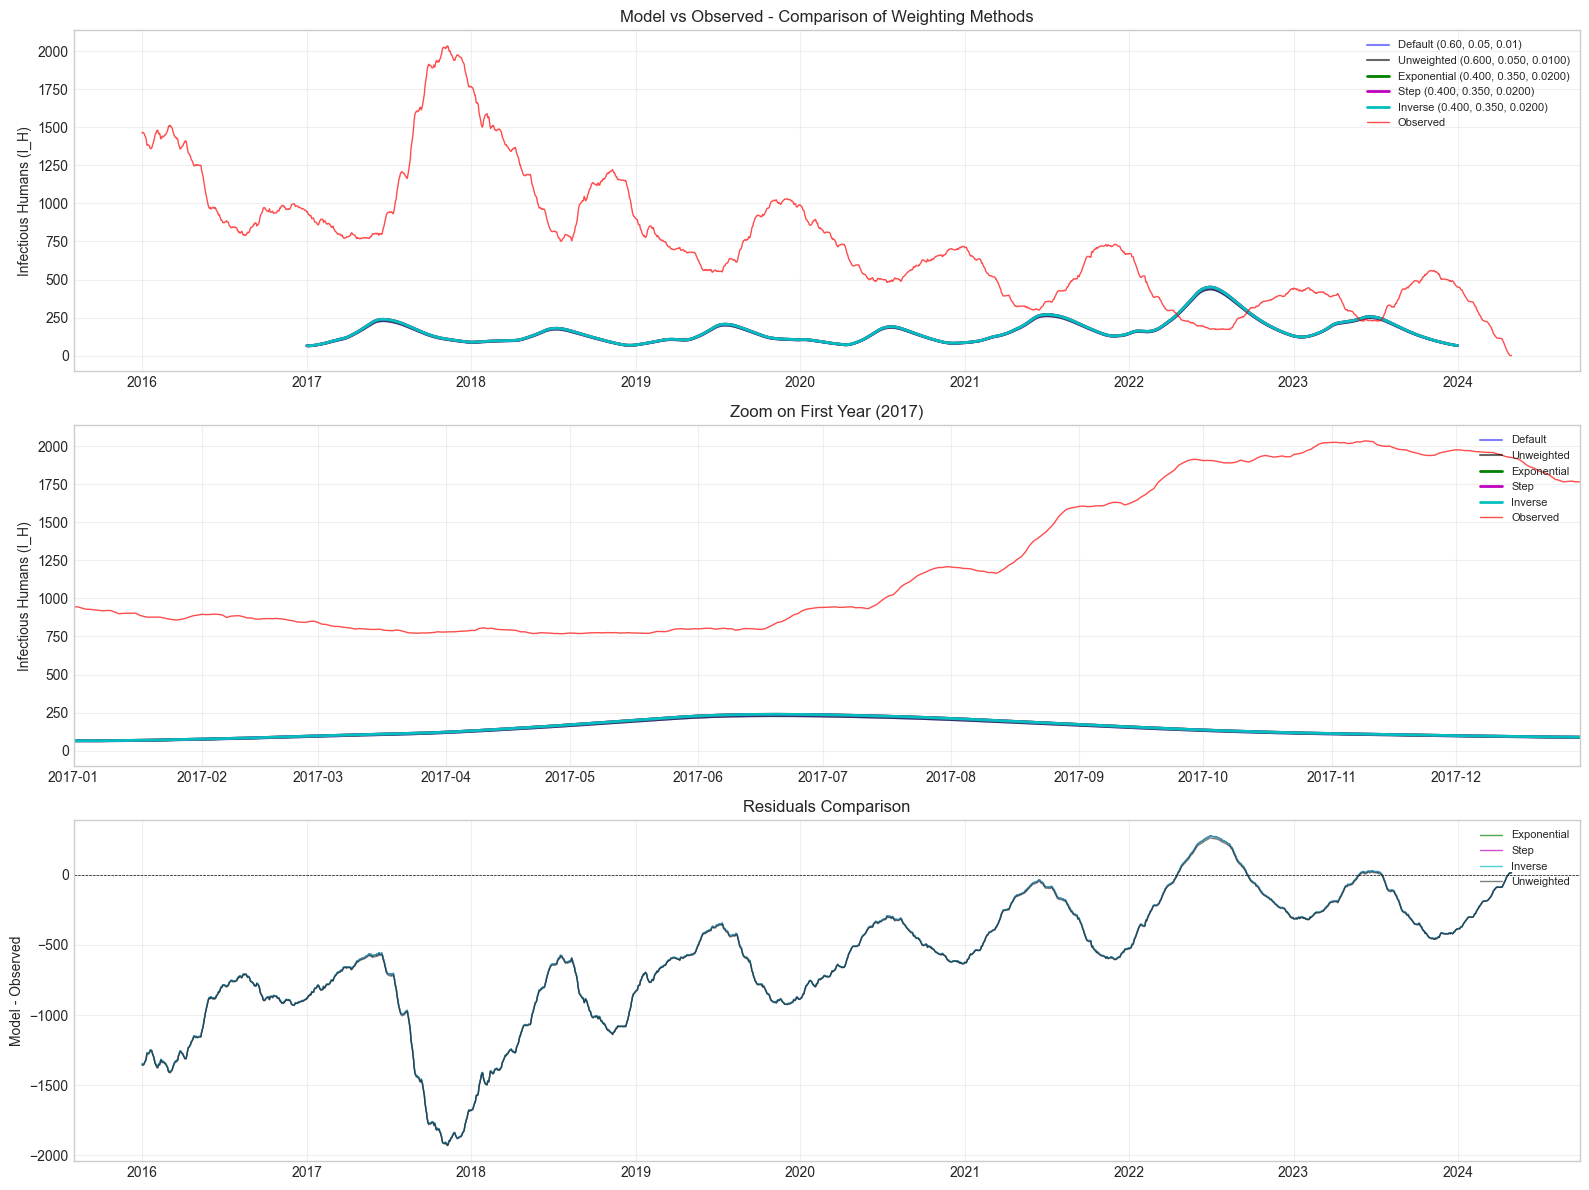

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default (0.60, 0.05, 0.01)')
ax1.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label=f'Unweighted ({S_H0_opt_unw:.3f}, {E_H0_opt_unw:.3f}, {I_M0_opt_unw:.4f})')
ax1.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label=f'Exponential ({S_H0_optimal_exp:.3f}, {E_H0_optimal_exp:.3f}, {I_M0_optimal_exp:.4f})')
ax1.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label=f'Step ({S_H0_optimal_step:.3f}, {E_H0_optimal_step:.3f}, {I_M0_optimal_step:.4f})')
ax1.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label=f'Inverse ({S_H0_optimal_inv:.3f}, {E_H0_optimal_inv:.3f}, {I_M0_optimal_inv:.4f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)'); ax1.set_title('Model vs Observed - Comparison of Weighting Methods')
ax1.legend(loc='upper right', fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
first_year_end = pd.to_datetime('2017-12-31')
ax2.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default')
ax2.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label='Unweighted')
ax2.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label='Exponential')
ax2.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label='Step')
ax2.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label='Inverse')
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax2.set_xlim(pd.to_datetime('2017-01-01'), first_year_end)
ax2.set_ylabel('Infectious Humans (I_H)'); ax2.set_title('Zoom on First Year (2017)')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
obs_dates_int = rural_cases_df['date'].astype(np.int64).values
for dates_arr, IH_arr, label, color, alpha in [
    (dates_exp, IH_exp, 'Exponential', 'g', 0.7),
    (dates_step, IH_step, 'Step', 'm', 0.7),
    (dates_inv, IH_inv, 'Inverse', 'c', 0.7),
    (dates_unw, IH_unw, 'Unweighted', 'k', 0.5),
]:
    mi = interp1d(pd.to_datetime(dates_arr).astype(np.int64), IH_arr, kind='linear', fill_value='extrapolate')
    ax3.plot(rural_cases_df['date'], mi(obs_dates_int) - rural_cases_df['active_total'].values,
             '-', color=color, linewidth=1.0, alpha=alpha, label=label)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Model - Observed'); ax3.set_title('Residuals Comparison')
ax3.legend(loc='upper right', fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Quantitative Comparison

In [20]:
def compute_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    return np.mean((mi(rural_cases_df['date'].astype(np.int64).values) - rural_cases_df['active_total'].values) ** 2)

def compute_first_year_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    mask = rural_cases_df['date'] <= pd.to_datetime('2017-12-31')
    return np.mean((mi(rural_cases_df.loc[mask, 'date'].astype(np.int64).values) - rural_cases_df.loc[mask, 'active_total'].values) ** 2)

method_results = {
    'Default':     {'dates': dates_default, 'IH': IH_default, 'S_H0_frac': 0.60, 'E_H0_frac': 0.05, 'I_M0_ratio': 0.01},
    'Unweighted':  {'dates': dates_unw,     'IH': IH_unw,     'S_H0_frac': S_H0_opt_unw, 'E_H0_frac': E_H0_opt_unw, 'I_M0_ratio': I_M0_opt_unw},
    'Exponential': {'dates': dates_exp,     'IH': IH_exp,     'S_H0_frac': S_H0_optimal_exp, 'E_H0_frac': E_H0_optimal_exp, 'I_M0_ratio': I_M0_optimal_exp},
    'Step':        {'dates': dates_step,    'IH': IH_step,    'S_H0_frac': S_H0_optimal_step, 'E_H0_frac': E_H0_optimal_step, 'I_M0_ratio': I_M0_optimal_step},
    'Inverse':     {'dates': dates_inv,     'IH': IH_inv,     'S_H0_frac': S_H0_optimal_inv, 'E_H0_frac': E_H0_optimal_inv, 'I_M0_ratio': I_M0_optimal_inv},
}

print("=" * 80)
print("QUANTITATIVE COMPARISON")
print("=" * 80)
print(f"{'Method':<15} {'Overall MSE':>15} {'First Year MSE':>15} {'S_H0_frac':>10} {'E_H0_frac':>10} {'I_M0_ratio':>12}")
print("-" * 80)

for name, data in method_results.items():
    overall = compute_mse(data['dates'], data['IH'])
    first_yr = compute_first_year_mse(data['dates'], data['IH'])
    print(f"{name:<15} {overall:>15,.2f} {first_yr:>15,.2f} {data['S_H0_frac']:>10.4f} {data['E_H0_frac']:>10.4f} {data['I_M0_ratio']:>12.6f}")

print("=" * 80)

QUANTITATIVE COMPARISON
Method              Overall MSE  First Year MSE  S_H0_frac  E_H0_frac   I_M0_ratio
--------------------------------------------------------------------------------
Default              574,789.26    1,267,497.71     0.6000     0.0500     0.010000
Unweighted           574,789.26    1,267,497.71     0.6000     0.0500     0.010000
Exponential          568,596.72    1,255,235.22     0.4000     0.3500     0.020000
Step                 568,596.72    1,255,235.22     0.4000     0.3500     0.020000
Inverse              568,596.72    1,255,235.22     0.4000     0.3500     0.020000


---
## Summary: Best Parameters

In [22]:
saved = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}

print("=" * 70)
print("BEST WEIGHTED PARAMETERS (Initial Conditions)")
print("=" * 70)

N_wu = N_warmup
M_0_wu = 10 * N_wu

for method in ['exponential', 'step', 'inverse']:
    params = saved.get(method, {})
    if params:
        s_val = params['S_H0_frac']
        e_val = params['E_H0_frac']
        im_val = params['I_M0_ratio']
        print(f"\n{method.upper()}:")
        print(f"  S_H0_frac = {s_val:.4f}  (S_H0 = {round(s_val * N_wu)} / N={N_wu})")
        print(f"  E_H0_frac = {e_val:.4f}  (E_H0 = {round(e_val * N_wu)} / N={N_wu})")
        print(f"  I_M0_ratio = {im_val:.6f}  (I_M0 = {round(im_val * M_0_wu)} / M_0={M_0_wu})")

print("\n" + "=" * 70)

BEST WEIGHTED PARAMETERS (Initial Conditions)

EXPONENTIAL:
  S_H0_frac = 0.4000  (S_H0 = 3566 / N=8914)
  E_H0_frac = 0.3500  (E_H0 = 3120 / N=8914)
  I_M0_ratio = 0.020000  (I_M0 = 1783 / M_0=89140)

STEP:
  S_H0_frac = 0.4000  (S_H0 = 3566 / N=8914)
  E_H0_frac = 0.3500  (E_H0 = 3120 / N=8914)
  I_M0_ratio = 0.020000  (I_M0 = 1783 / M_0=89140)

INVERSE:
  S_H0_frac = 0.4000  (S_H0 = 3566 / N=8914)
  E_H0_frac = 0.3500  (E_H0 = 3120 / N=8914)
  I_M0_ratio = 0.020000  (I_M0 = 1783 / M_0=89140)

